In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 6)

In [15]:
df = pd.read_csv('C:\\Users\\hp\\predictive-maintenance-ml-datascience-project\\data\\ai4i2020.csv')
print(f"Shape : {df.shape}")
print(f"\nColonnes : {list(df.columns)}")
df.head()

Shape : (10000, 14)

Colonnes : ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


🔹 Variables du dataset AI4I 2020

🆔 Identification

UID : identifiant unique de chaque observation

Product ID : identifiant du produit

Type : catégorie du produit (L = Low, M = Medium, H = High)


⚙️ Variables explicatives (features)

Air temperature (K) : température ambiante autour de la machine

Process temperature (K) : température du processus de fabrication

Rotational speed (rpm) : vitesse de rotation de la machine

Torque (Nm) : couple appliqué (force de rotation)

Tool wear (min) : durée d’usure de l’outil

🎯 Variable cible

Machine failure : indique si la machine est en panne (0 = non, 1 = oui)

🔧 Types de pannes

TWF (Tool Wear Failure) : panne due à l’usure de l’outil

HDF (Heat Dissipation Failure) : panne liée à une surchauffe

PWF (Power Failure) : panne liée à un problème de puissance

OSF (Overstrain Failure) : panne due à une surcharge

RNF (Random Failure) : panne aléatoire

💡 Remarque (optionnel à ajouter)

La variable Machine failure vaut 1 lorsqu’au moins un des types de pannes (TWF, HDF, PWF, OSF, RNF) est activé.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [17]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [18]:
missing = df.isnull().sum()
print("Valeurs manquantes :\n", missing)

Valeurs manquantes :
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64


In [19]:
print("Distribution des pannes :")
print(df['Machine failure'].value_counts())
print(f"\nTaux de panne : {df['Machine failure'].mean()*100:.2f}%")

Distribution des pannes :
Machine failure
0    9661
1     339
Name: count, dtype: int64

Taux de panne : 3.39%


Ce que ça veut dire concrètement:   
Sur 10 000 machines, seulement 339 sont tombées en panne — soit 3.39%. C'est ce qu'on appelle un dataset déséquilibré, et c'est réaliste : dans la vraie industrie, les pannes sont rares.

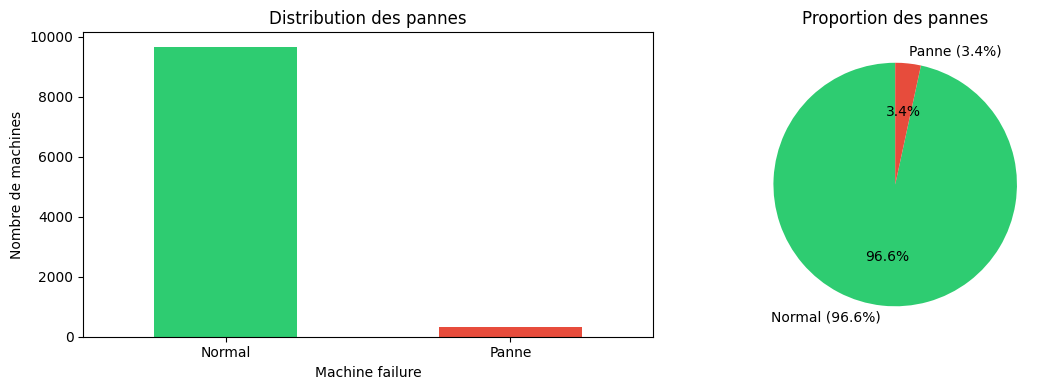

In [20]:
# Visualiser le déséquilibre
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
df['Machine failure'].value_counts().plot(
    kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Distribution des pannes')
axes[0].set_xticklabels(['Normal', 'Panne'], rotation=0)
axes[0].set_ylabel('Nombre de machines')

# Pie chart
axes[1].pie(
    df['Machine failure'].value_counts(),
    labels=['Normal (96.6%)', 'Panne (3.4%)'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Proportion des pannes')

plt.tight_layout()
plt.savefig('../data/eda_desequilibre.png', dpi=150)
plt.show()

Détail des types de pannes :
HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64


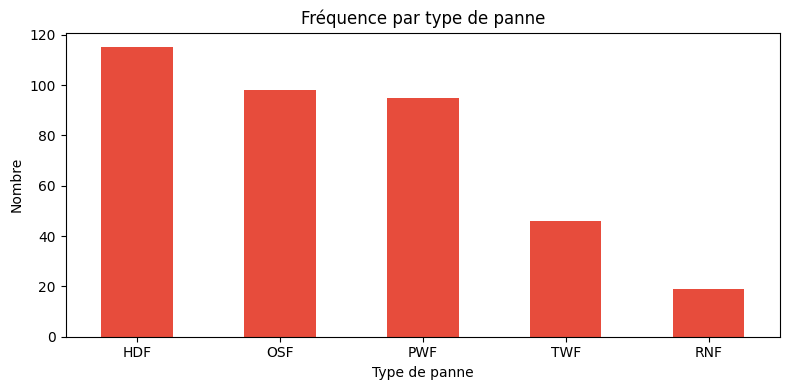

In [21]:
#Types de pannes détaillés
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df[failure_cols].sum().sort_values(ascending=False)

print("Détail des types de pannes :")
print(failure_counts)

failure_counts.plot(kind='bar', color='#e74c3c', figsize=(8, 4))
plt.title('Fréquence par type de panne')
plt.xlabel('Type de panne')
plt.ylabel('Nombre')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../data/eda_types_pannes.png', dpi=150)
plt.show()

L'insight clé à retenir :     

les pannes HDF et OSF sont les plus fréquentes et les plus prévisibles car elles dépendent directement des features qu'on a : température, couple, vitesse. Les RNF (aléatoires) sont quasi impossibles à prédire — c'est normal et honnête de le mentionner dans ton README.

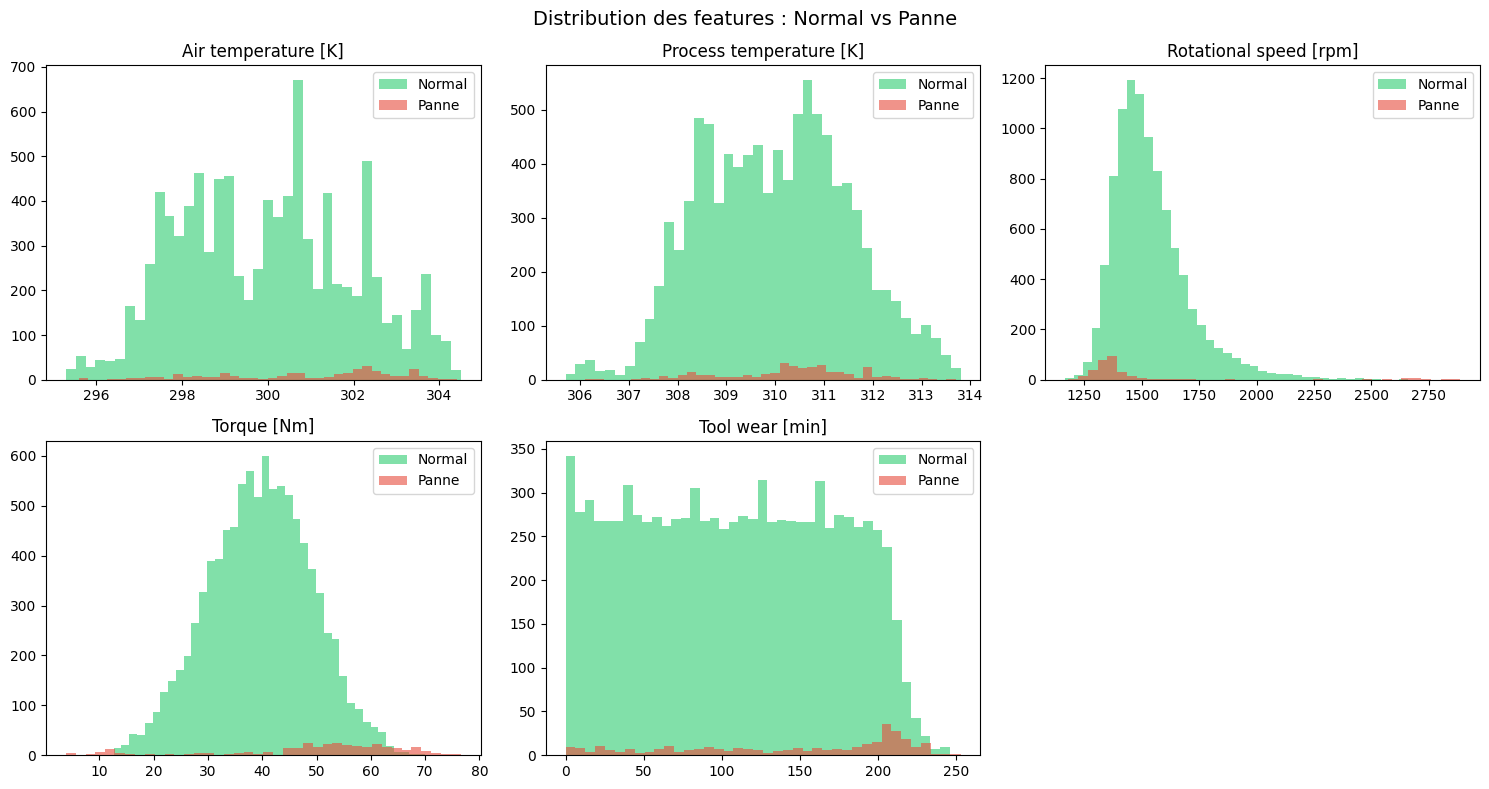

In [22]:
#Distribution des features numériques

num_features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(
        df[df['Machine failure']==0][col],
        bins=40, alpha=0.6, color='#2ecc71', label='Normal'
    )
    axes[i].hist(
        df[df['Machine failure']==1][col],
        bins=40, alpha=0.6, color='#e74c3c', label='Panne'
    )
    axes[i].set_title(col)
    axes[i].legend()

axes[-1].axis('off')
plt.suptitle('Distribution des features : Normal vs Panne', fontsize=14)
plt.tight_layout()
plt.savefig('../data/eda_distributions.png', dpi=150)
plt.show()

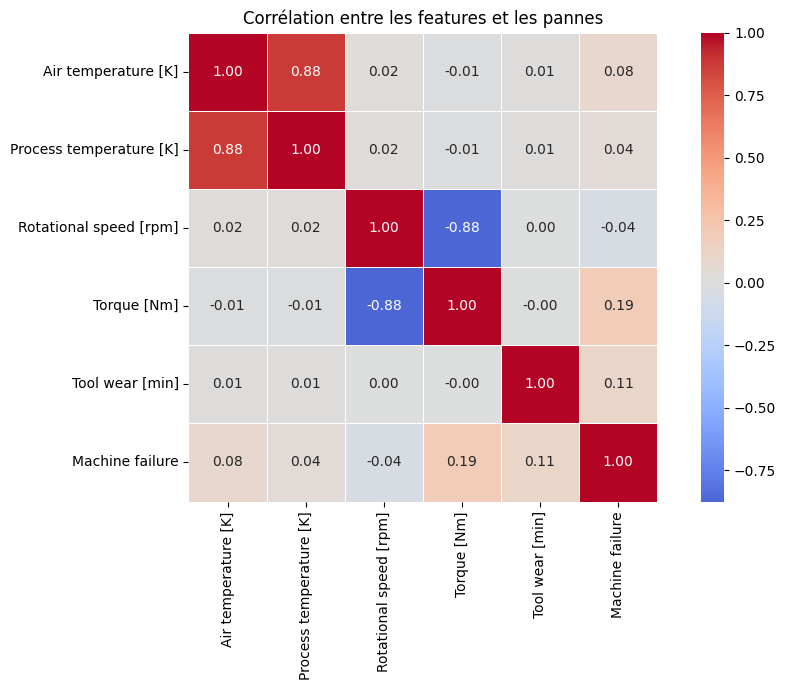

In [23]:
#Heatmap de corrélation

plt.figure(figsize=(10, 7))
corr = df[num_features + ['Machine failure']].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Corrélation entre les features et les pannes')
plt.tight_layout()
plt.savefig('../data/eda_correlation.png', dpi=150)
plt.show()

Les deux insights clés :

Premièrement, Torque et Tool wear sont les features les plus liées aux pannes — ce sont tes features les plus importantes, SHAP va confirmer ça plus tard.

Deuxièmement, Rotational speed et Torque ont une corrélation de -0.88 entre eux — quand la vitesse monte, le couple baisse. C'est une relation physique réelle entre ces deux variables. Ça veut dire qu'elles apportent une information similaire au modèle — à garder en tête.

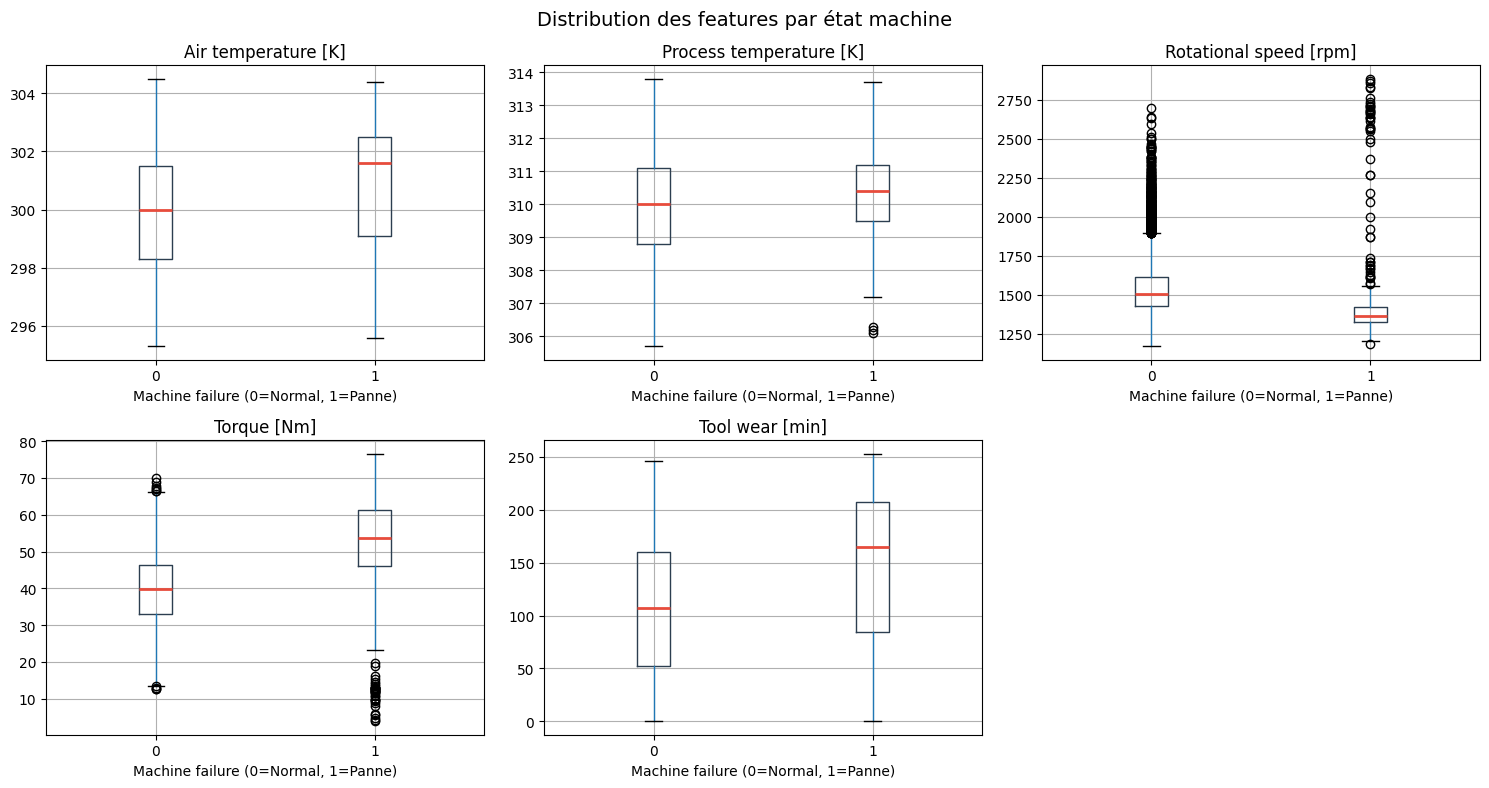

In [24]:
#Boxplots des features par état machine
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    df.boxplot(
        column=col,
        by='Machine failure',
        ax=axes[i],
        boxprops=dict(color='#2c3e50'),
        medianprops=dict(color='#e74c3c', linewidth=2)
    )
    axes[i].set_title(col)
    axes[i].set_xlabel('Machine failure (0=Normal, 1=Panne)')
    axes[i].set_ylabel('')

axes[-1].axis('off')
plt.suptitle('Distribution des features par état machine', fontsize=14)
plt.tight_layout()
plt.savefig('../data/eda_boxplots.png', dpi=150)
plt.show()

In [25]:
#Résumé final de l'EDA
print("=" * 50)
print("RÉSUMÉ EDA — INSIGHTS CLÉS")
print("=" * 50)
print(f"\n Taille dataset     : {df.shape[0]} lignes, {df.shape[1]} colonnes")
print(f" Valeurs manquantes : {df.isnull().sum().sum()}")
print(f" Taux de panne      : {df['Machine failure'].mean()*100:.2f}%")
print(f"\n Type de panne le + fréquent : HDF (Heat Dissipation) — {df['HDF'].sum()} cas")
print(f" Feature + corrélée panne    : Torque [Nm] (r=0.19)")
print(f" Corrélation forte détectée  : RPM vs Torque (r=-0.88)")
print(f"\n Dataset prêt pour le preprocessing ")
print("=" * 50)

RÉSUMÉ EDA — INSIGHTS CLÉS

 Taille dataset     : 10000 lignes, 14 colonnes
 Valeurs manquantes : 0
 Taux de panne      : 3.39%

 Type de panne le + fréquent : HDF (Heat Dissipation) — 115 cas
 Feature + corrélée panne    : Torque [Nm] (r=0.19)
 Corrélation forte détectée  : RPM vs Torque (r=-0.88)

 Dataset prêt pour le preprocessing 
